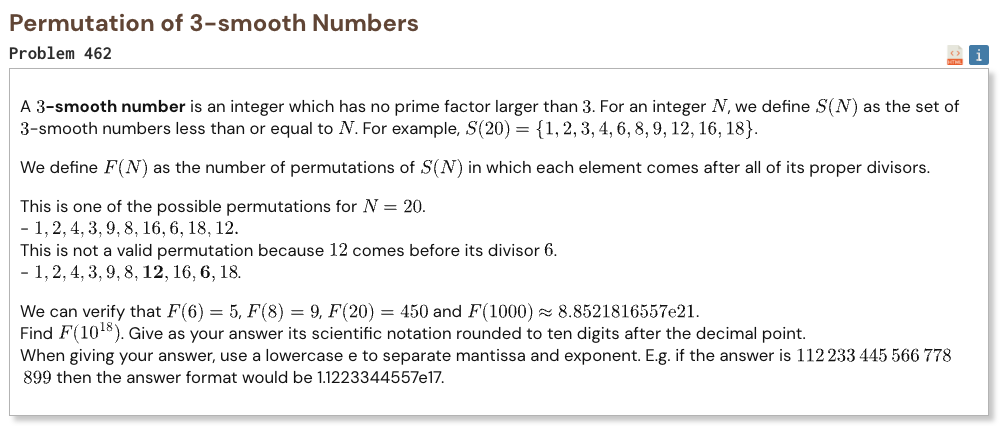

## Initial approach

-   every 3-smooth number can be written using only powers of 2 and 3
-   represent each number by the pair of exponents of 2 and 3
-   one number divides another exactly when both of its exponents are no larger
-   these exponent pairs form a Young diagram, where valid permutations correspond to valid increasing fillings
-   count these fillings with the hook length formula instead of checking permutations directly
-   build the row lengths using integer arithmetic so there are no floating point logarithm errors
-   multiply all hook lengths, divide the factorial of the number of cells by this product, then format the exact integer
-   use the math library for the factorial

In [1]:
%%time

import math

N = 10**18

rows = []
power_of_three = 1

while power_of_three <= N:
    bound = N // power_of_three
    rows.append(bound.bit_length())

    if power_of_three > N // 3:
        break

    power_of_three *= 3

column_heights = []

for column in range(rows[0]):
    height = sum(
        1
        for row_length in rows
        if row_length > column
    )
    column_heights.append(height)

cell_count = sum(rows)

hook_product = 1

for row, row_length in enumerate(rows):
    for column in range(row_length):
        cells_right = row_length - column - 1
        cells_below = column_heights[column] - row - 1
        hook_length = cells_right + cells_below + 1
        hook_product *= hook_length

result = math.factorial(cell_count) // hook_product

digits = str(result)
exponent = len(digits) - 1

leading = int(digits[:11])
round_digit = int(digits[11])

if round_digit >= 5:
    leading += 1

if leading == 100000000000:
    leading = 10000000000
    exponent += 1

mantissa = f"{leading // 10**10}.{leading % 10**10:010d}"
result = f"{mantissa}e{exponent}"

print("Result:", result)

Result: 5.5350769703e1512
CPU times: user 1.04 ms, sys: 22 μs, total: 1.06 ms
Wall time: 1.07 ms
